# Comparativa de métricas de inferencia

Este notebook compara throughput, latencia, perplejidad y eficiencia
energética entre los modelos disponibles.

**Nota metodológica**: `tokens/s` no es directamente comparable entre
modelos con tokenizers distintos (cada modelo parte el texto de forma
diferente). `words/s` (palabras por segundo) es la métrica "user-perceived"
y sí es honestamente comparable.

In [1]:
"""Carga de todos los runs."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "raw_runs"

assert DATA_ROOT.is_dir(), f"❌ No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
prompt_df = coll.prompt_metrics_df()
valid = prompt_df[
    (~prompt_df["is_empty_generation"]) &
    (prompt_df["latency_ms"] > 0)
].copy()

print(f"Runs: {prompt_df['run_id'].nunique()}")
print(f"Prompts totales: {len(prompt_df)}, válidos (no vacíos): {len(valid)}")
print(f"Modelos: {', '.join(valid['model_short'].unique())}")

tokenProb size mismatch in run=mnistral prompt=0: got 836 tokens, eval_count=849


Runs: 4
Prompts totales: 10, válidos (no vacíos): 7
Modelos: gemma3n:e2b, granite4:micro-h, ministral-3:3b, tinyllama-1.1b-chat-v1.0.Q4_0


## Throughput: tokens/s y palabras/s

`tokens/s` es la métrica interna del motor. `palabras/s` es lo que percibe
el usuario y es comparable entre modelos con tokenizers distintos.

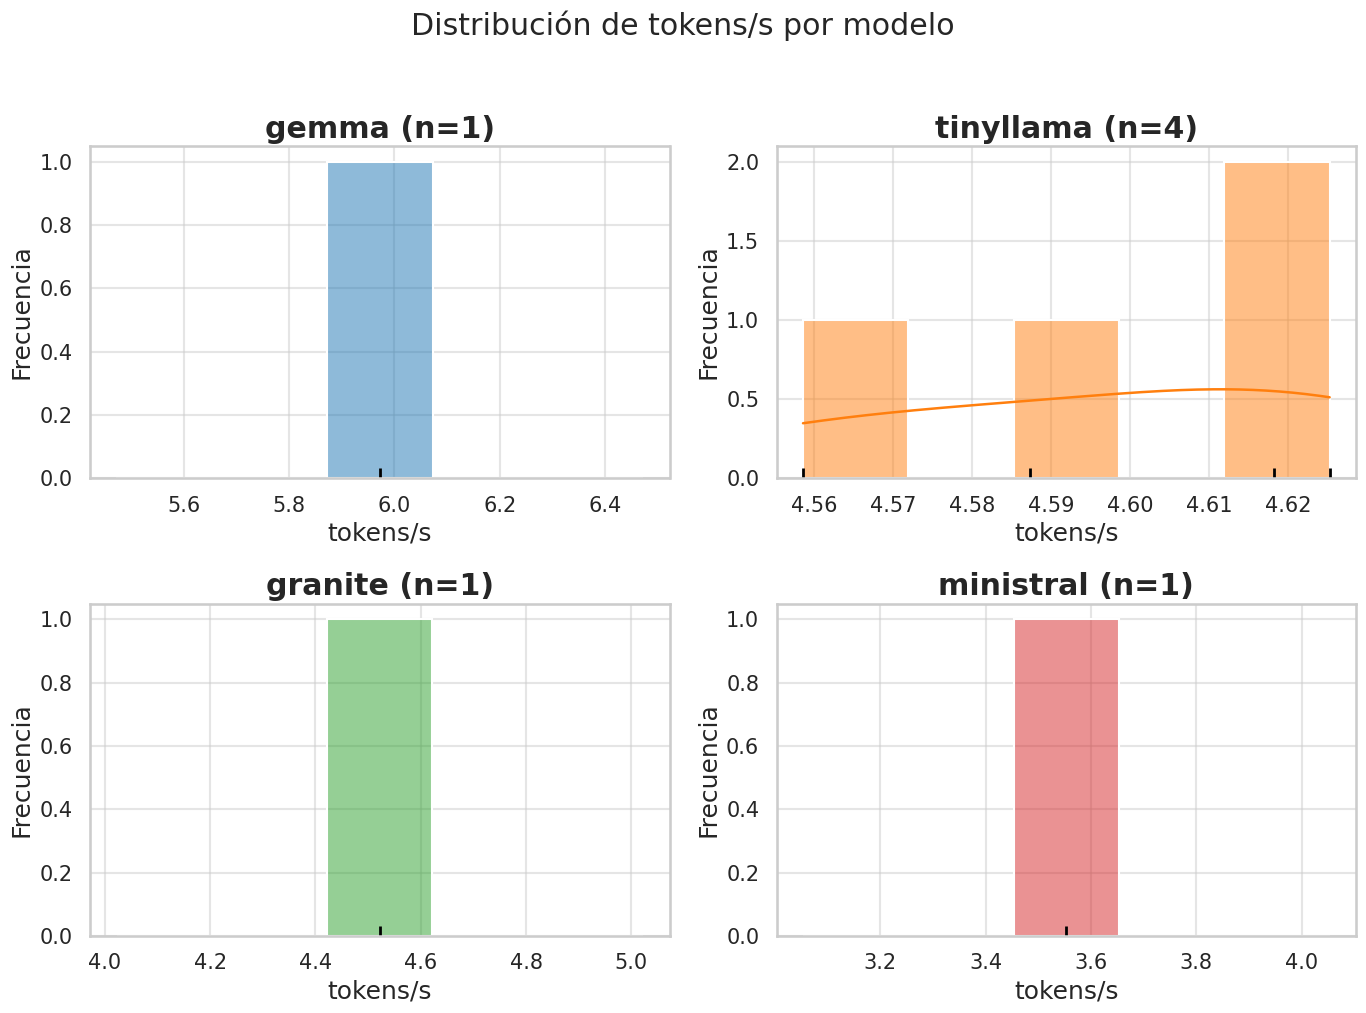

In [2]:
order = valid.groupby("model_label")["tokens_per_second"].mean().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes_flat = axes.flatten()

for i, model in enumerate(order):
    ax = axes_flat[i]
    model_data = valid[valid["model_label"] == model]
    sns.histplot(
        data=model_data, x="tokens_per_second",
        bins=5, kde=True, ax=ax,
        color=f"C{i}",
    )
    ax.plot(
        model_data["tokens_per_second"],
        [0] * len(model_data),
        "|", color="black", markersize=15, markeredgewidth=2,
    )
    ax.set_title(f"{model} (n={len(model_data)})")
    ax.set_xlabel("tokens/s")
    ax.set_ylabel("Frecuencia")

for j in range(len(order), 4):
    axes_flat[j].set_visible(False)

fig.suptitle("Distribución de tokens/s por modelo", y=1.02)
fig.tight_layout()
plt.show()


## Latencia

Tiempo total por prompt (carga + prefill + decode + overhead).

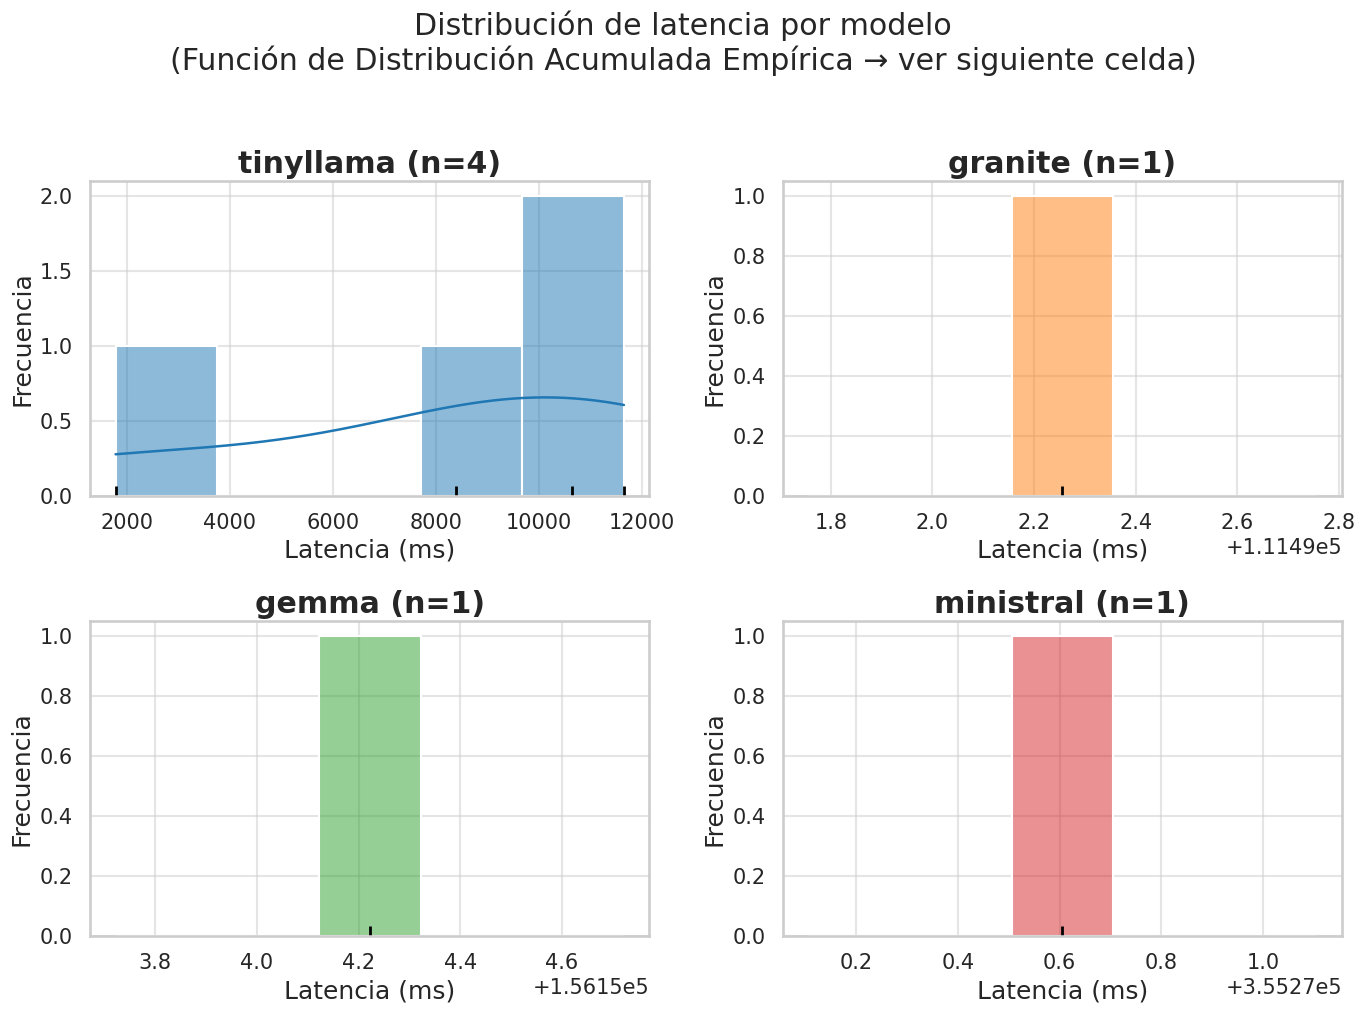

/tmp/ipykernel_273070/523286470.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")


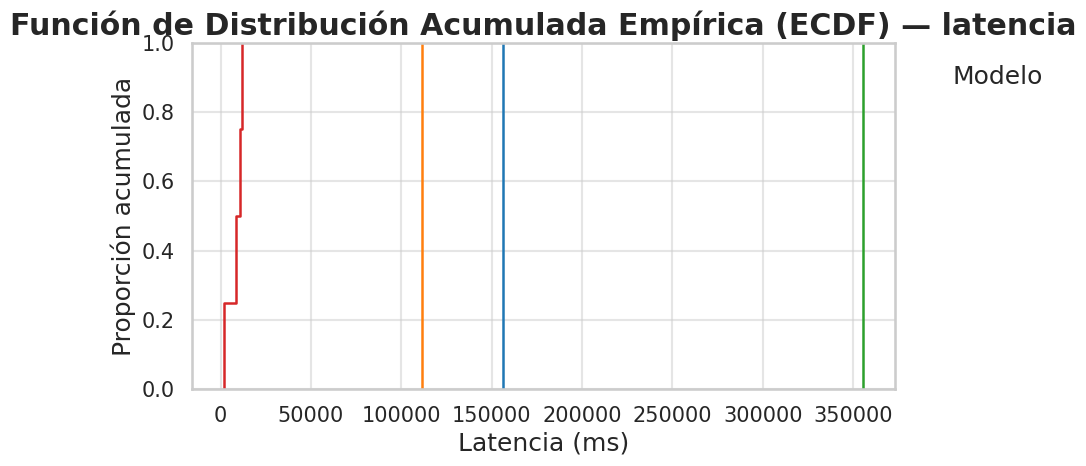

In [3]:
order_lat = valid.groupby("model_label")["latency_ms"].mean().sort_values().index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes_flat = axes.flatten()

for i, model in enumerate(order_lat):
    ax = axes_flat[i]
    model_data = valid[valid["model_label"] == model]
    sns.histplot(
        data=model_data, x="latency_ms",
        bins=5, kde=True, ax=ax,
        color=f"C{i}",
    )
    ax.plot(
        model_data["latency_ms"],
        [0] * len(model_data),
        "|", color="black", markersize=15, markeredgewidth=2,
    )
    ax.set_title(f"{model} (n={len(model_data)})")
    ax.set_xlabel("Latencia (ms)")
    ax.set_ylabel("Frecuencia")

for j in range(len(order_lat), 4):
    axes_flat[j].set_visible(False)

fig.suptitle("Distribución de latencia por modelo\n(Función de Distribución Acumulada Empírica → ver siguiente celda)", y=1.02)
fig.tight_layout()
plt.show()

# ECDF separado (más legible sin superponer histogramas de 4 modelos)
fig2, ax2 = plt.subplots(figsize=(10, 5))
sns.ecdfplot(data=valid, x="latency_ms", hue="model_label", ax=ax2)
ax2.set_title("Función de Distribución Acumulada Empírica (ECDF) — latencia")
ax2.set_xlabel("Latencia (ms)")
ax2.set_ylabel("Proporción acumulada")
ax2.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
fig2.tight_layout()
plt.show()


## Time to First Token (TTFT)

Tiempo desde que se envía el prompt hasta que llega el primer token
de respuesta. Es `load_duration + prompt_eval_duration`. Métrica
importante para la experiencia de usuario interactiva.

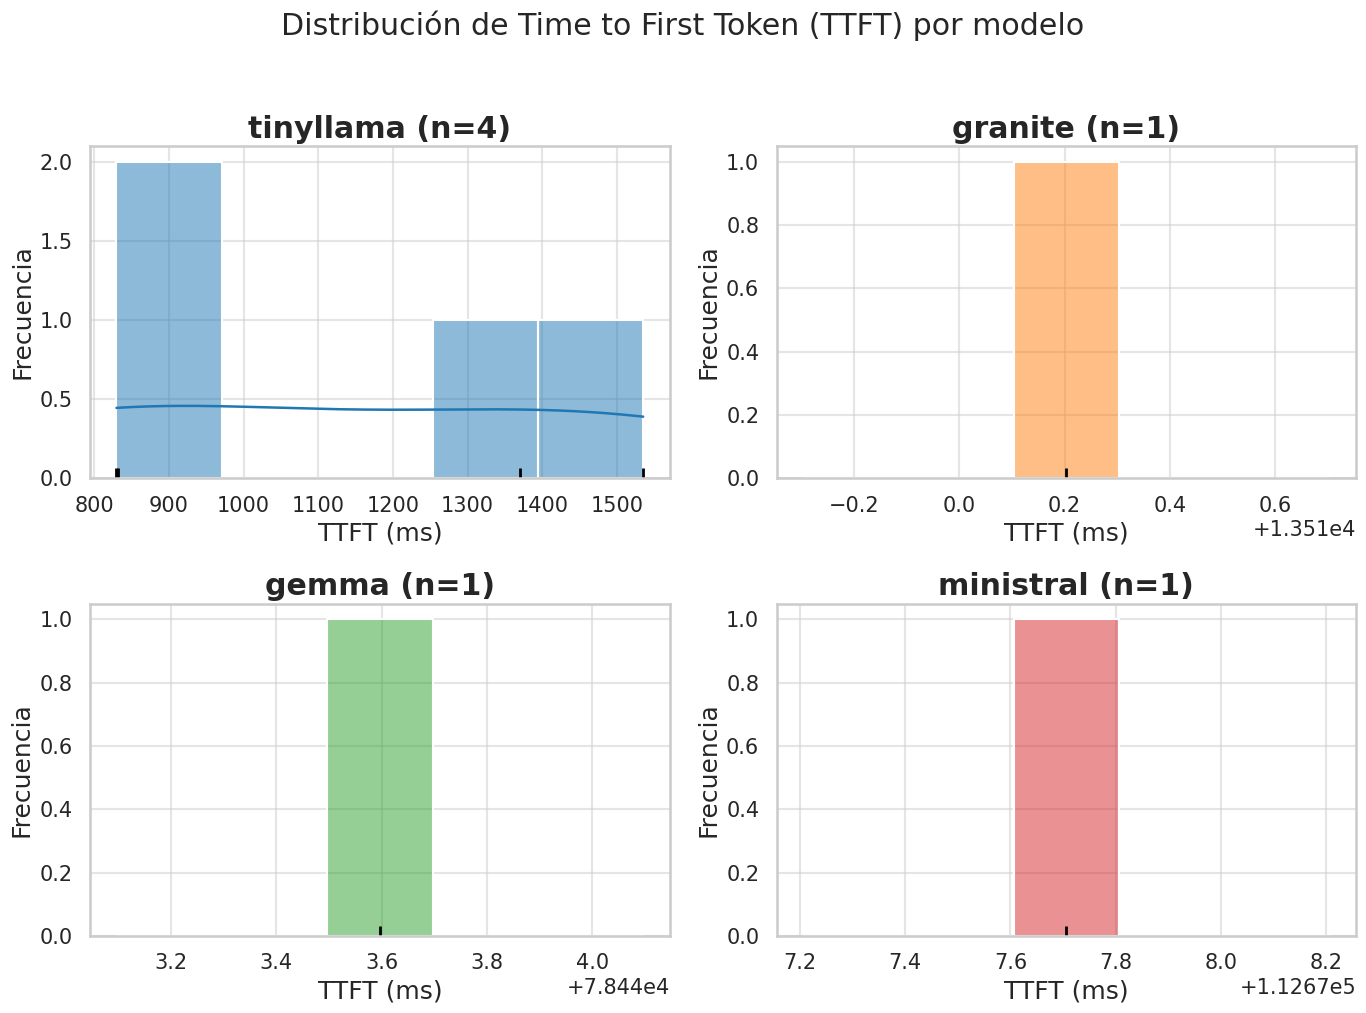

In [4]:
order_ttft = valid.groupby("model_label")["time_to_first_token_ms"].mean().sort_values().index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes_flat = axes.flatten()

for i, model in enumerate(order_ttft):
    ax = axes_flat[i]
    model_data = valid[valid["model_label"] == model]
    sns.histplot(
        data=model_data, x="time_to_first_token_ms",
        bins=5, kde=True, ax=ax, color=f"C{i}",
    )
    ax.plot(
        model_data["time_to_first_token_ms"],
        [0] * len(model_data),
        "|", color="black", markersize=15, markeredgewidth=2,
    )
    ax.set_title(f"{model} (n={len(model_data)})")
    ax.set_xlabel("TTFT (ms)")
    ax.set_ylabel("Frecuencia")

for j in range(len(order_ttft), 4):
    axes_flat[j].set_visible(False)

fig.suptitle("Distribución de Time to First Token (TTFT) por modelo", y=1.02)
fig.tight_layout()
plt.show()


## Perplejidad

La perplejidad mide la confianza del modelo sobre los tokens que generó.
Valores bajos (cercanos a 1) indican alta confianza.

**Importante**: la perplejidad **no es comparable** directamente entre
modelos con tokenizers distintos. Sin embargo, sí es comparable entre
ejecuciones del mismo modelo con configuraciones distintas.

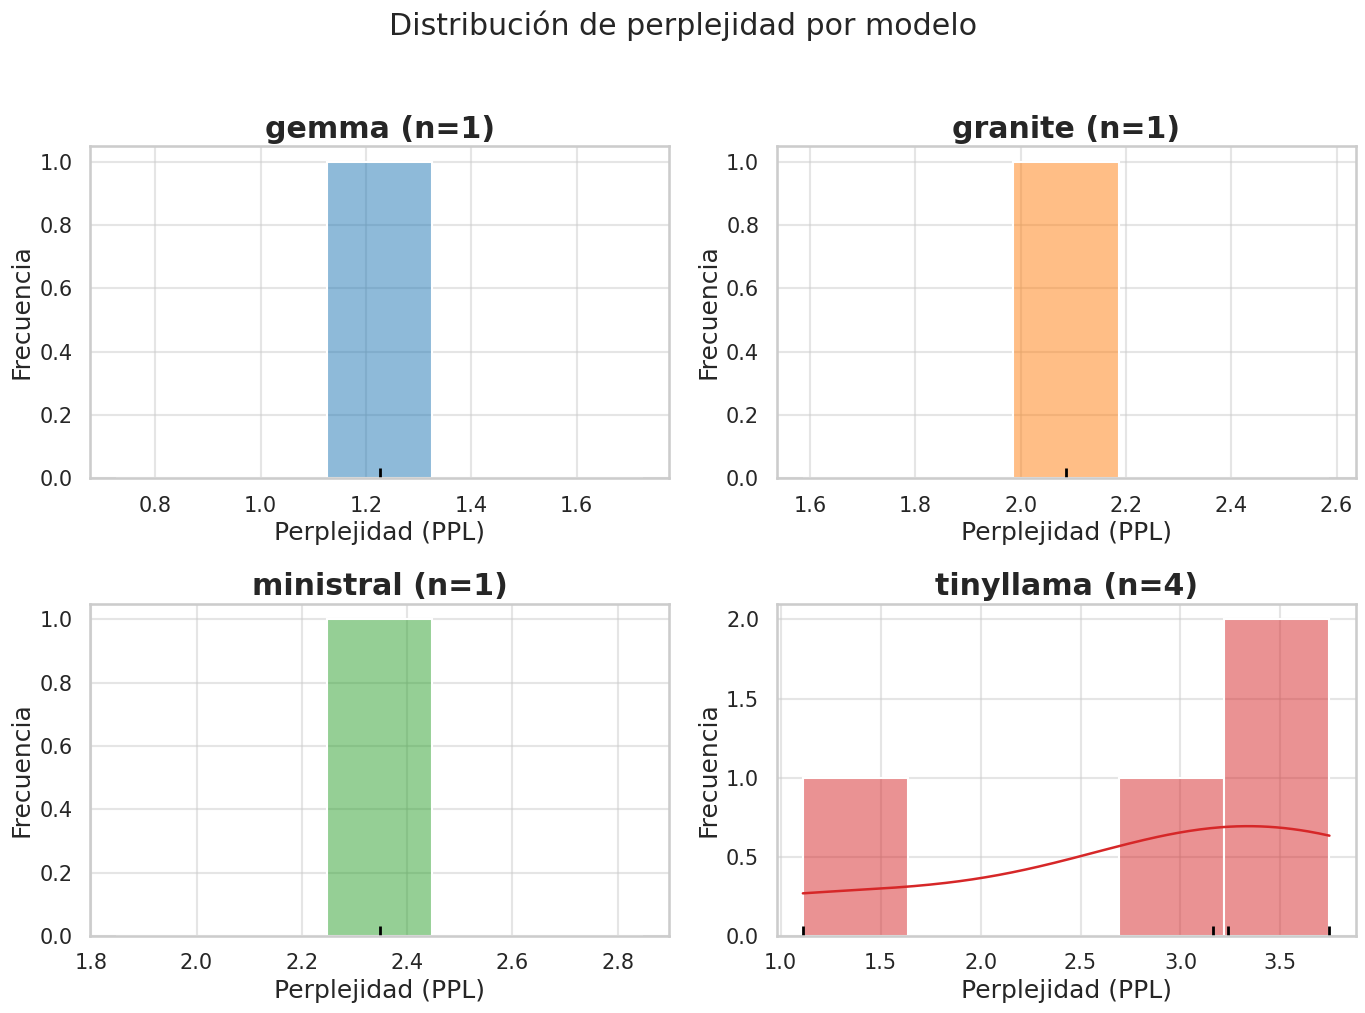

In [5]:
ppl_valid = valid.dropna(subset=["perplexity"])
if ppl_valid.empty:
    print("No hay datos de perplejidad disponibles.")
else:
    order_ppl = ppl_valid.groupby("model_label")["perplexity"].mean().sort_values().index.tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
    axes_flat = axes.flatten()

    for i, model in enumerate(order_ppl):
        ax = axes_flat[i]
        model_data = ppl_valid[ppl_valid["model_label"] == model]
        sns.histplot(
            data=model_data, x="perplexity",
            bins=5, kde=True, ax=ax, color=f"C{i}",
        )
        ax.plot(
            model_data["perplexity"],
            [0] * len(model_data),
            "|", color="black", markersize=15, markeredgewidth=2,
        )
        ax.set_title(f"{model} (n={len(model_data)})")
        ax.set_xlabel("Perplejidad (PPL)")
        ax.set_ylabel("Frecuencia")

    for j in range(len(order_ppl), 4):
        axes_flat[j].set_visible(False)

    fig.suptitle("Distribución de perplejidad por modelo", y=1.02)
    fig.tight_layout()
    plt.show()


## Desglose de fases

Proporción del tiempo total que cada prompt pasa en load, prefill y decode.
El decode (generación secuencial token a token) es típicamente >85% del
total en modelos corriendo en CPU.

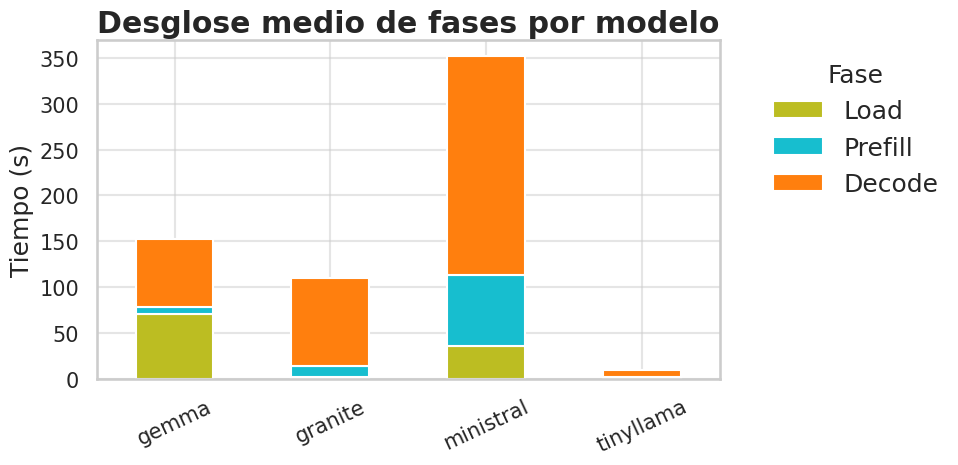

In [6]:
phases = valid.assign(
    Load=valid["load_duration_ns"] / 1e9,
    Prefill=valid["prompt_eval_duration_ns"] / 1e9,
    Decode=valid["eval_duration_ns"] / 1e9,
)
phase_means = (
    phases.groupby("model_label")[["Load", "Prefill", "Decode"]].mean()
)
ax = phase_means.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["#bcbd22", "#17becf", "#ff7f0e"],
    rot=25,
)
ax.set_title("Desglose medio de fases por modelo")
ax.set_ylabel("Tiempo (s)")
ax.set_xlabel("")
ax.legend(title="Fase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Tabla resumen

Medias agregadas por modelo con las métricas clave. Esta tabla se puede
copiar directamente a la memoria del TFG.

In [7]:
summary = (
    valid.groupby("model_label")
    .agg(
        n_prompts=("prompt_id", "count"),
        tokens_per_s=("tokens_per_second", "mean"),
        words_per_s=("words_per_second", "mean"),
        latency_s=("latency_ms", lambda x: x.mean() / 1000),
        latency_p95_s=("latency_ms", lambda x: x.quantile(0.95) / 1000),
        ttft_s=("time_to_first_token_ms", lambda x: x.mean() / 1000),
        perplexity=("perplexity", "mean"),
        eval_count_mean=("eval_count", "mean"),
    )
    .round(3)
)
summary


,n_prompts,tokens_per_s,words_per_s,latency_s,latency_p95_s,ttft_s,perplexity,eval_count_mean
model_label,,,,,,,,
gemma,1,5.972,4.713,156.154,156.154,78.444,1.226,441.0
granite,1,4.522,3.786,111.492,111.492,13.510,2.087,436.0
ministral,1,3.553,2.825,355.271,355.271,112.678,2.348,849.0
tinyllama,4,4.597,3.823,8.118,11.505,1.142,2.814,36.5


## Consumo de potencia por fase de inferencia

La inferencia se divide en tres fases con naturaleza computacional distinta:

- **Load**: carga del modelo en RAM. Operación de I/O, bajo consumo.
- **Prefill**: lectura y procesamiento del prompt, construcción del KV-cache.
  Computación paralela (similar a un forward pass completo), pico de consumo.
- **Decode**: generación secuencial token a token. Computación intensiva
  y sostenida, determina el consumo durante la mayor parte del run.

La fase de `load` suele durar <300 ms, menos que el periodo de muestreo
de hardware (~1 s), por lo que la media de potencia durante `load` puede
no tener muestras suficientes para ser fiable (se marca como `NaN`).


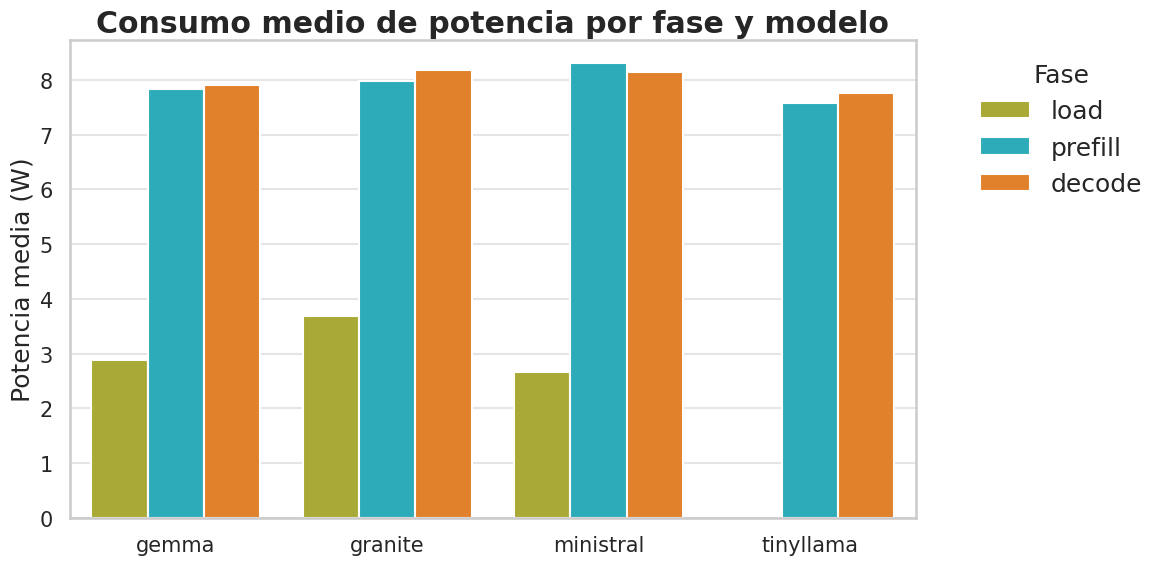


Tabla de potencia media por fase (W):
phase        load  prefill  decode
model_label                       
gemma        2.88     7.83    7.91
granite      3.69     7.98    8.18
ministral    2.66     8.31    8.14
tinyllama     NaN     7.58    7.76


In [8]:
from monitorviz.transforms import power_per_phase_df

phase_df = coll.power_per_phase_df()

# Filter out rows with no hw samples (especially load)
phase_valid = phase_df[
    (phase_df["n_hw_samples"] > 0) &
    (phase_df["power_mean_w"].notna())
].copy()

if phase_valid.empty:
    print("Sin datos de potencia por fase (puede que falten hw runs).")
else:
    # Mean across prompts per (model, phase)
    phase_summary = (
        phase_valid.groupby(["model_label", "phase"])["power_mean_w"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "power_mean_w", "std": "power_std_w", "count": "n_prompts"})
        .reset_index()
    )

    # Bar chart grouped by phase
    phase_order = ["load", "prefill", "decode"]
    phase_summary["phase"] = pd.Categorical(
        phase_summary["phase"], categories=phase_order, ordered=True
    )
    phase_summary = phase_summary.sort_values(["phase", "model_label"])

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=phase_summary, x="model_label", y="power_mean_w",
        hue="phase", hue_order=phase_order,
        palette=["#bcbd22", "#17becf", "#ff7f0e"],
        ax=ax,
    )
    ax.set_title("Consumo medio de potencia por fase y modelo")
    ax.set_xlabel("")
    ax.set_ylabel("Potencia media (W)")
    ax.legend(title="Fase", bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

    # Table
    print("\nTabla de potencia media por fase (W):")
    pivot = phase_summary.pivot(index="model_label", columns="phase", values="power_mean_w").round(2)
    print(pivot.to_string())
